# Notebook 03 — GRU (From Scratch)

**Model**: 2-layer stacked GRU (Gated Recurrent Unit)  
**Why GRU?** Simpler than LSTM (2 gates vs 4), faster training, fewer parameters, comparable accuracy.  
**Input**: `(batch, 12, 207)` → **Output**: `(batch, 207)`

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pickle

from utils.data_utils  import load_processed, make_loaders, inverse_transform
from utils.metrics     import compute_all_metrics, print_metrics
from utils.train_utils import EarlyStopping, full_train, predict_all, count_parameters

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed('../data/processed')
train_loader, val_loader, test_loader = make_loaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size_train=32, batch_size_eval=64
)
N_SENSORS = X_train.shape[2]

[load] Loaded processed data from ../data/processed\processed_data.pkl
[loaders] Train:23978  Val:3415  Test:6843


## 1. GRU Architecture

In [3]:
class GRUTrafficPredictor(nn.Module):
    """
    2-layer stacked GRU for multi-sensor traffic prediction.

    GRU vs LSTM:
    ┌─────────────┬──────────┬──────────┐
    │             │  LSTM    │  GRU     │
    ├─────────────┼──────────┼──────────┤
    │ Gates       │  4       │  2+1     │
    │ Cell state  │  Yes     │  No      │
    │ Parameters  │  ~185K   │  ~140K   │
    │ Training    │  Slower  │  Faster  │
    └─────────────┴──────────┴──────────┘

    GRU combines forget & input gates into a single update gate.
    """

    def __init__(self, n_sensors=207, hidden_size=64, num_layers=2,
                 dropout=0.2, fc_hidden=128):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_sensors,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, fc_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, n_sensors),
        )

    def forward(self, x):
        gru_out, _ = self.gru(x)       # (batch, T, hidden)
        last_h = gru_out[:, -1, :]     # (batch, hidden)
        return self.fc(last_h)         # (batch, N)


model = GRUTrafficPredictor(n_sensors=N_SENSORS).to(device)
print(f'Parameters: {count_parameters(model):,}')
print(model)

Parameters: 112,399
GRUTrafficPredictor(
  (gru): GRU(207, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=207, bias=True)
  )
)


## 2. Training

In [4]:
criterion  = nn.MSELoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
early_stop = EarlyStopping(patience=10, path='../models/gru_best.pth')

train_losses, val_losses = full_train(
    model, train_loader, val_loader,
    optimizer, criterion, scheduler, early_stop,
    device, max_epochs=100, model_name='GRU'
)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training GRU on cuda
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch    1/100 | train=0.043544 | val=0.025822
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.025822)
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.022319)
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.020379)
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.018700)
  Epoch    5/100 | train=0.019690 | val=0.018220
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.018220)
  EarlyStopping counter: 1/10
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.017994)
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.017733)
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.017273)
  Epoch   10/100 | train=0.017318 | val=0.017141
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.017141)
  EarlyStopping counter: 1/10
  ✓ Best model saved → ../models/gru_best.pth  (val_loss=0.01686

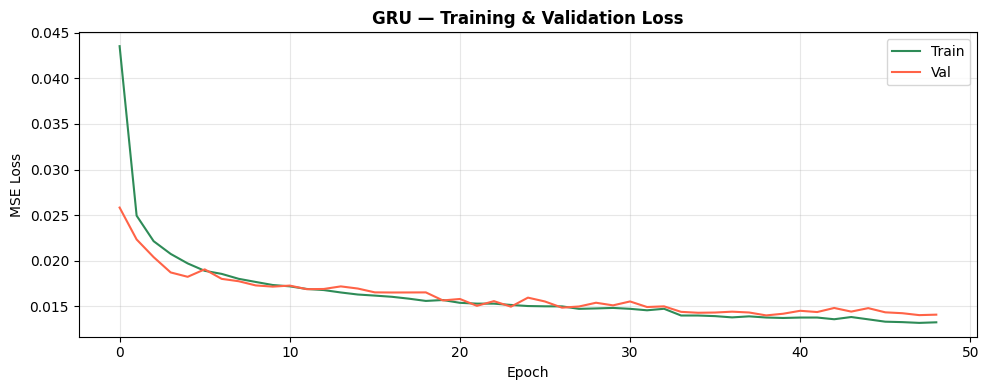

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train', color='seagreen')
ax.plot(val_losses,   label='Val',   color='tomato')
ax.set_title('GRU — Training & Validation Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/gru_training_curve.png', dpi=150)
plt.show()

## 3. Evaluation

In [7]:
preds_norm, labels_norm = predict_all(model, test_loader, device)
preds  = inverse_transform(preds_norm, scaler)
labels = inverse_transform(labels_norm, scaler)

metrics = compute_all_metrics(preds, labels)
print_metrics(metrics, 'GRU (From Scratch)')

with open('../results/gru_metrics.pkl', 'wb') as f:
    pickle.dump({'model': 'GRU', 'metrics': metrics,
                 'train_losses': train_losses, 'val_losses': val_losses,
                 'params': count_parameters(model)}, f)
print('✅ Metrics saved → results/gru_metrics.pkl')


  GRU (From Scratch) — Evaluation Metrics
  MAE  : 4.9858 km/h
  RMSE : 9.8460 km/h
  MAPE : 10.30 %
  R²   : 0.8132

✅ Metrics saved → results/gru_metrics.pkl


## 4. Prediction Visualization

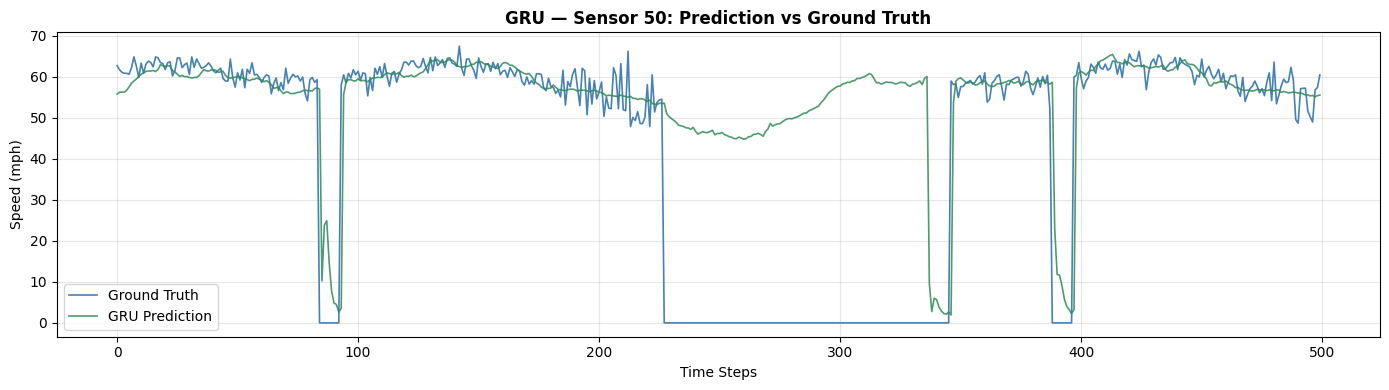

In [8]:
sensor_idx = 50
n_show     = 500

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(labels[:n_show, sensor_idx], label='Ground Truth', color='steelblue', lw=1.2)
ax.plot(preds[:n_show,  sensor_idx], label='GRU Prediction', color='seagreen', lw=1.2, alpha=0.85)
ax.set_title(f'GRU — Sensor {sensor_idx}: Prediction vs Ground Truth', fontweight='bold')
ax.set_xlabel('Time Steps'); ax.set_ylabel('Speed (mph)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/gru_prediction_viz.png', dpi=150)
plt.show()